In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4090


In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB5, EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
import seaborn as sns

2025-07-22 23:21:09.552197: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-22 23:21:09.561468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753204869.572918  724273 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753204869.576475  724273 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753204869.586263  724273 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
# ------------------------------
# Data Preparation
# ------------------------------

def get_data_generators(train_dir, val_dir, test_dir, img_size, batch_size):
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest')

    val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    val_generator = val_test_datagen.flow_from_directory(
        val_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical')

    test_generator = val_test_datagen.flow_from_directory(
        test_dir, target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False)

    return train_generator, val_generator, test_generator

In [4]:
# ------------------------------
# Teacher Model - EfficientNetB5
# ------------------------------

def create_teacher_model(input_shape, num_classes, dropout_rate):
    base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(1024, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(512, activation='swish')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [5]:
# ------------------------------
# Student Model - EfficientNetB0
# ------------------------------

def create_student_model(input_shape, num_classes, dropout_rate=0.3):
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True  # Fine-tune if desired

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='swish')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model

In [6]:
# ------------------------------
# Knowledge Distillation Logic
# ------------------------------

def distillation_loss(y_true, y_pred, teacher_pred, temperature, alpha):
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    soft_loss = tf.keras.losses.KLDivergence()(
        tf.nn.softmax(teacher_pred / temperature),
        tf.nn.softmax(y_pred / temperature))
    return alpha * hard_loss + (1 - alpha) * soft_loss

def train_student_with_distillation(student, teacher, train_gen, val_gen, epochs, temperature, alpha):
    optimizer = Adam()

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")
        for i in range(len(train_gen)):
            x_batch, y_batch = train_gen[i]
            teacher_preds = teacher.predict(x_batch)

            with tf.GradientTape() as tape:
                student_preds = student(x_batch, training=True)
                loss = distillation_loss(y_batch, student_preds, teacher_preds, temperature, alpha)

            grads = tape.gradient(loss, student.trainable_variables)
            optimizer.apply_gradients(zip(grads, student.trainable_variables))

        student.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        val_loss, val_acc = student.evaluate(val_gen, verbose=0)
        print(f"Validation Accuracy: {val_acc:.4f}")

    return student

In [7]:
# ------------------------------
# Evaluation
# ------------------------------

def evaluate_model(model, test_generator, class_names):
    test_loss, test_acc = model.evaluate(test_generator)
    print("Test Accuracy:", test_acc)

    predictions = model.predict(test_generator)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes

    conf_matrix = confusion_matrix(true_classes, predicted_classes)
    class_report = classification_report(true_classes, predicted_classes, target_names=class_names)
    precision = precision_score(true_classes, predicted_classes, average='weighted')
    recall = recall_score(true_classes, predicted_classes, average='weighted')
    f1 = f1_score(true_classes, predicted_classes, average='weighted')

    print("Confusion Matrix:\n", conf_matrix)
    print("\nClassification Report:\n", class_report)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 20})
    plt.xlabel('Predicted', fontsize=20)
    plt.ylabel('True', fontsize=20)
    plt.title('Confusion Matrix', fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

Found 1614 images belonging to 5 classes.
Found 230 images belonging to 5 classes.
Found 466 images belonging to 5 classes.


I0000 00:00:1753206291.729090  724273 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9444 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
/mnt/d/FA011/tf_gpu_env/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1753206312.330611  728399 service.cc:152] XLA service 0x7ed548003a50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753206312.330637  728399 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2025-07-22 23:45:12.728822: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1753206314.840572  728399 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-07-22 23:45:17.299576: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30311', 204 bytes spill stores, 204 bytes spill loads

2025-07-22 23:45:17.389175: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.3404 - loss: 1.4439

...

51/51 ━━━━━━━━━━━━━━━━━━━━ 81s 865ms/step - accuracy: 0.3454 - loss: 1.4377 - val_accuracy: 0.3435 - val_loss: 1.6604
Epoch 2/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.4845 - loss: 1.1838 - val_accuracy: 0.5826 - val_loss: 1.0270
Epoch 3/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.5530 - loss: 1.1295 - val_accuracy: 0.5435 - val_loss: 1.0651
Epoch 4/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 192ms/step - accuracy: 0.5853 - loss: 1.0199 - val_accuracy: 0.6652 - val_loss: 0.8112
Epoch 5/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.5874 - loss: 0.9839 - val_accuracy: 0.5913 - val_loss: 0.9249
Epoch 6/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.6130 - loss: 0.9456 - val_accuracy: 0.5913 - val_loss: 1.0931
Epoch 7/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - accuracy: 0.6173 - loss: 0.9478 - val_accuracy: 0.6565 - val_loss: 0.7357
Epoch 8/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 193ms/step - accuracy: 0.6381 - loss: 0.9053 - val_accuracy: 0.617

2025-07-22 23:58:11.674930: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 204 bytes spill stores, 204 bytes spill loads

2025-07-22 23:58:11.686524: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076_0', 464 bytes spill stores, 1372 bytes spill loads

2025-07-22 23:58:11.948217: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 5616 bytes spill stores, 5612 bytes spill loads

2025-07-22 23:58:11.968247: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 5340 bytes spill stores, 5324 bytes spill loads

2025-07-22 23:58:12.88939

Validation Accuracy: 0.2913

Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

2025-07-23 00:07:35.000386: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076_0', 444 bytes spill stores, 1384 bytes spill loads

2025-07-23 00:07:35.017989: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 8 bytes spill stores, 8 bytes spill loads

2025-07-23 00:07:35.047526: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 220 bytes spill stores, 220 bytes spill loads

2025-07-23 00:07:35.288341: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2076', 5524 bytes spill stores, 5564 bytes spill loads

2025-07-23 00:07:35.316739: I e

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 438ms/step - accuracy: 0.7308 - loss: 0.8890
Test Accuracy: 0.7360514998435974
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 233ms/step
Confusion Matrix:
 [[80 12  6  3  0]
 [14 69 14  2  0]
 [ 2 36 45  7  4]
 [ 1  3  2 72 11]
 [ 0  4  1  1 77]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.81       101
           1       0.56      0.70      0.62        99
           2       0.66      0.48      0.56        94
           3       0.85      0.81      0.83        89
           4       0.84      0.93      0.88        83

    accuracy                           0.74       466
   macro avg       0.75      0.74      0.74       466
weighted avg       0.74      0.74      0.73       466

Precision: 0.7413
Recall: 0.7361
F1 Score: 0.7335


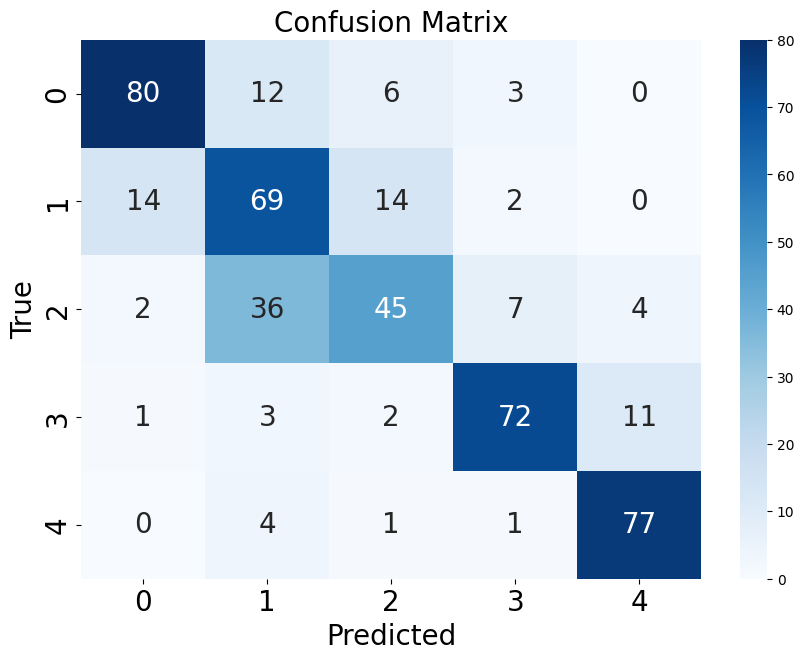

In [10]:
# ------------------------------
# Main
# ------------------------------

if __name__ == "__main__":
    train_dir = '/mnt/d/FA019/SplitDataset/train'
    val_dir = '/mnt/d/FA019/SplitDataset/val'
    test_dir = '/mnt/d/FA019/SplitDataset/test'

    img_size = (224, 224)
    input_shape = (img_size[0], img_size[1], 3)
    batch_size = 32
    dropout_rate = 0.5
    num_classes = len(os.listdir(train_dir))
    class_names = sorted(os.listdir(train_dir))

    train_gen, val_gen, test_gen = get_data_generators(train_dir, val_dir, test_dir, img_size, batch_size)

    # Train teacher model
    teacher = create_teacher_model(input_shape, num_classes, dropout_rate)
    teacher.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    teacher.fit(train_gen, epochs=60, validation_data=val_gen)

    # Create student model
    # Create Student using EfficientNetB0
    student = create_student_model(input_shape, num_classes, dropout_rate=0.5)


    # Train with distillation
    trained_student = train_student_with_distillation(
        student, teacher, train_gen, val_gen,
        epochs=10, temperature=3.0, alpha=0.3
    )

    # Final evaluation
    evaluate_model(trained_student, test_gen, class_names)